# 레거시 발전량 예측 모델

이 노트북은 확보할 수 없는 운영 코드 대신, 대표적인 `Mean`, `Weather`, `ForecastWeather`, `Ldaps`, `SPOT` 모델을 결정론적 합성 데이터로 재구성한 교육용 예제입니다. 따라서 실제 독점 구현을 복제한 것이 아닙니다.

`Weather`는 실제 관측치를 사용하므로 사후 분석용 오라클입니다. 이후 AIDM의 기준선으로 내보내는 모델은 예측 시점 입력만 사용하는 `SPOT`입니다.

In [3]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from power_forecasting.data import validate_dataset

SEED = 42
ARTIFACT_DIR = Path("artifacts/legacy_notebook")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def generate_legacy_demo_data(days=90, plants=4, seed=SEED):
    rng = np.random.default_rng(seed)
    records = []
    for timestamp in pd.date_range("2024-03-01", periods=days * 24, freq="h"):
        daylight = max(0.0, math.sin(math.pi * (timestamp.hour - 6) / 12))
        seasonal = 0.80 + 0.18 * math.cos(2 * math.pi * (timestamp.dayofyear - 172) / 365)
        for plant_index in range(plants):
            capacity_mw = 42.0 + plant_index * 13.0
            actual_cloud_cover = float(np.clip(0.40 + 0.12 * math.sin(2 * math.pi * (timestamp.hour + plant_index) / 24) + rng.normal(0, 0.07), 0, 1))
            actual_temperature = 20 + 7 * seasonal + 7 * math.sin(2 * math.pi * (timestamp.hour - 8) / 24) + rng.normal(0, 1.2)
            actual_wind_speed = float(np.clip(4 + rng.normal(0, 0.8), 0, None))
            clear_sky_irradiance = 990 * daylight * seasonal
            actual_irradiance = float(np.clip(clear_sky_irradiance * (1 - 0.72 * actual_cloud_cover) + rng.normal(0, 18 * daylight), 0, None))
            forecast_cloud_cover = float(np.clip(actual_cloud_cover + rng.normal(0.02, 0.11), 0, 1))
            forecast_temperature = float(actual_temperature + rng.normal(0.2, 2.0))
            forecast_wind_speed = float(np.clip(actual_wind_speed + rng.normal(0, 1.1), 0, None))
            forecast_irradiance = float(np.clip(clear_sky_irradiance * (1 - 0.67 * forecast_cloud_cover) + rng.normal(0, 45 * daylight), 0, None))
            ldaps_cloud_cover = float(np.clip(actual_cloud_cover + rng.normal(0, 0.07), 0, 1))
            ldaps_temperature = float(actual_temperature + rng.normal(0, 1.1))
            ldaps_irradiance = float(np.clip(actual_irradiance + rng.normal(0, 28 * daylight), 0, None))
            ldaps_humidity = float(np.clip(58 + 28 * actual_cloud_cover - 0.45 * (actual_temperature - 25) + rng.normal(0, 4), 5, 100))
            generation_mw = float(np.clip(capacity_mw * (actual_irradiance / 1000) * (0.90 + plant_index * 0.025) * (1 - 0.0045 * max(0, actual_temperature - 25)), 0, capacity_mw))
            records.append({"plant_id": f"plant_{plant_index + 1:02d}", "timestamp": timestamp, "capacity_mw": capacity_mw, "latitude": 33.0 + plant_index * 2.7, "longitude": 126.0 + plant_index * 1.9, "actual_irradiance": actual_irradiance, "actual_temperature": actual_temperature, "actual_cloud_cover": actual_cloud_cover, "actual_wind_speed": actual_wind_speed, "forecast_irradiance": forecast_irradiance, "forecast_temperature": forecast_temperature, "forecast_cloud_cover": forecast_cloud_cover, "forecast_wind_speed": forecast_wind_speed, "ldaps_irradiance": ldaps_irradiance, "ldaps_temperature": ldaps_temperature, "ldaps_cloud_cover": ldaps_cloud_cover, "ldaps_humidity": ldaps_humidity, "generation_mw": generation_mw})
    return pd.DataFrame(records).sort_values(["timestamp", "plant_id"]).reset_index(drop=True)


def chronological_holdout(frame, train_fraction=0.8):
    timestamps = frame["timestamp"].drop_duplicates().sort_values().to_numpy()
    cutoff = timestamps[int(len(timestamps) * train_fraction)]
    return frame.loc[frame["timestamp"] < cutoff].copy(), frame.loc[frame["timestamp"] >= cutoff].copy()


def metric_values(frame):
    error = frame["prediction_mw"] - frame["generation_mw"]
    return {"MAE": float(error.abs().mean()), "RMSE": float(np.sqrt((error ** 2).mean())), "NMAE": float(error.abs().sum() / frame["capacity_mw"].sum())}


def ridge_pipeline():
    return make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), Ridge(alpha=1.0))


def predict_mean(train, holdout):
    hourly = train.assign(hour=train["timestamp"].dt.hour).groupby(["plant_id", "hour"])["generation_mw"].mean()
    fallback = train.groupby("plant_id")["generation_mw"].mean()
    keys = pd.MultiIndex.from_arrays([holdout["plant_id"], holdout["timestamp"].dt.hour])
    values = hourly.reindex(keys).to_numpy(dtype=float)
    return np.where(np.isnan(values), holdout["plant_id"].map(fallback).to_numpy(), values)


def evaluate(name, availability, features=None, factory=None):
    if name == "Mean":
        prediction = predict_mean(train, holdout)
    else:
        estimator = factory().fit(train[features], train["generation_mw"])
        prediction = estimator.predict(holdout[features])
    result = holdout[["plant_id", "timestamp", "generation_mw", "capacity_mw"]].copy()
    result["prediction_mw"] = np.clip(prediction, 0, result["capacity_mw"])
    result["model"] = name
    result["availability"] = availability
    return result


dataset = generate_legacy_demo_data()
validate_dataset(dataset)
train, holdout = chronological_holdout(dataset)
WEATHER_FEATURES = ["actual_irradiance", "actual_temperature", "actual_cloud_cover", "actual_wind_speed", "capacity_mw"]
FORECAST_WEATHER_FEATURES = ["forecast_irradiance", "forecast_temperature", "forecast_cloud_cover", "forecast_wind_speed", "capacity_mw"]
LDAPS_FEATURES = ["ldaps_irradiance", "ldaps_temperature", "ldaps_cloud_cover", "ldaps_humidity", "capacity_mw"]
SPOT_FEATURES = FORECAST_WEATHER_FEATURES + ["latitude", "longitude"]
models = {
    "Mean": evaluate("Mean", "historical"),
    "Weather": evaluate("Weather", "actual (oracle)", WEATHER_FEATURES, ridge_pipeline),
    "ForecastWeather": evaluate("ForecastWeather", "forecast", FORECAST_WEATHER_FEATURES, ridge_pipeline),
    "Ldaps": evaluate("Ldaps", "forecast", LDAPS_FEATURES, ridge_pipeline),
    "SPOT": evaluate("SPOT", "forecast (AIDM baseline)", SPOT_FEATURES, lambda: make_pipeline(SimpleImputer(strategy="median"), HistGradientBoostingRegressor(random_state=SEED, max_iter=100))),
}
model_metrics = pd.DataFrame([{"model": name, "availability": frame["availability"].iat[0], **metric_values(frame)} for name, frame in models.items()]).sort_values("NMAE")
per_plant_metrics = pd.concat([frame.groupby("plant_id", group_keys=False).apply(lambda group: pd.Series(metric_values(group))).assign(model=name).reset_index() for name, frame in models.items()], ignore_index=True)
dataset.to_csv(ARTIFACT_DIR / "dataset.csv", index=False)
model_metrics.to_csv(ARTIFACT_DIR / "model_metrics.csv", index=False)
per_plant_metrics.to_csv(ARTIFACT_DIR / "per_plant_metrics.csv", index=False)
legacy_predictions = models["SPOT"][["plant_id", "timestamp", "prediction_mw"]]
assert not legacy_predictions.duplicated(["plant_id", "timestamp"]).any()
legacy_predictions.to_csv(ARTIFACT_DIR / "legacy_predictions.csv", index=False)
model_metrics

/var/folders/pr/hngks2mn74d25jycvx6rxl400000gn/T/ipykernel_62893/1819179330.py:96: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_plant_metrics = pd.concat([frame.groupby("plant_id", group_keys=False).apply(lambda group: pd.Series(metric_values(group))).assign(model=name).reset_index() for name, frame in models.items()], ignore_index=True)
/var/folders/pr/hngks2mn74d25jycvx6rxl400000gn/T/ipykernel_62893/1819179330.py:96: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grou

,model,availability,MAE,RMSE,NMAE
4,SPOT,forecast (AIDM baseline),1.034858,2.090063,0.016827
0,Mean,historical,1.431394,2.720521,0.023275
1,Weather,actual (oracle),2.377341,3.641166,0.038656
3,Ldaps,forecast,2.421689,3.734165,0.039377
2,ForecastWeather,forecast,2.897569,4.599850,0.047115


In [9]:
def workspace_root(start):
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise RuntimeError("run this notebook from inside the power-forecasting workspace")


baseline_per_plant_metrics = pd.concat(
    [
        frame.groupby("plant_id", group_keys=False)
        .apply(lambda group: pd.Series(metric_values(group)))
        .assign(model=name)
        .reset_index()
        for name, frame in models.items()
    ],
    ignore_index=True,
)
ARTIFACT_DIR = workspace_root(Path.cwd()) / "artifacts" / "legacy_notebook"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
for artifact_name, artifact_frame in {
    "dataset.csv": dataset,
    "model_metrics.csv": model_metrics,
    "per_plant_metrics.csv": baseline_per_plant_metrics,
    "legacy_predictions.csv": legacy_predictions,
}.items():
    artifact_frame.to_csv(ARTIFACT_DIR / artifact_name, index=False)
print(f"Artifacts: {ARTIFACT_DIR}")

Artifacts: /Users/andy/works/ai/ml-harness/artifacts/legacy_notebook


/var/folders/pr/hngks2mn74d25jycvx6rxl400000gn/T/ipykernel_62893/1050163909.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: pd.Series(metric_values(group)))
/var/folders/pr/hngks2mn74d25jycvx6rxl400000gn/T/ipykernel_62893/1050163909.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: pd.Series(metric_values(group)))
/var/folders/pr/hngks2mn74d25jycvx6rxl400000gn/T/ipyke

## 제한된 탐색 연구: 피처, Optuna, 앙상블

이 절은 저장소 로컬 AIDM 실험 계약을 연구의 경계로 사용합니다. 즉, 5개 시간순 개발 fold, 고정 시드, 그리고 `.agents/skills/aidm-experiment`에서 허용한 이산 후보값만 사용하는 제한된 LightGBM Optuna TPE 탐색을 적용합니다.

예보 전용 피처와 예보 이력 피처는 예측 시점에 사용할 수 있습니다. 반면 발전량 이력 피처는 AIDM 제안 피처가 아니라 교육용 운영 시나리오로 분리해 평가합니다.

- `short_horizon_observed_history`: 예측을 발행하기 전에 관측된 발전량만 사용할 수 있는 단기 예측 시나리오입니다.
- `day_ahead_recursive`: 이후 시점의 이력 피처에 이전 예측값을 되먹임하는 하루 전 재귀 예측 시나리오입니다. Holdout 실제값은 사용하지 않습니다.

최종 20% holdout은 피처, Optuna 파라미터, 앙상블 가중치, stacking 계수 선택에 사용하지 않습니다.

AIDM-aligned bounded Optuna search: {'trials': 6, 'best_parameters': {'n_estimators': 300, 'learning_rate': 0.03, 'num_leaves': 15, 'min_child_samples': 10}, 'best_oof_nmae': 0.014283677596132584}
Forecast-only ensemble weights: {'ridge': 0.145, 'hgb': 0.419, 'lightgbm': 0.435}
Target-history comparison: positive NMAE_change_vs_forecast_hgb means the history bundle hurt relative to the forecast-only HGB baseline.


,model,feature_group,scenario,NMAE,MAE,RMSE,NMAE_change_vs_forecast_hgb
5,hgb,full_history,short_horizon_observed_history,0.012598,0.774805,1.553277,-0.002234
6,hgb,full_history,day_ahead_recursive,0.012688,0.780287,1.562405,-0.002145
4,hgb,lag_24_roll_24,short_horizon_observed_history,0.012920,0.794578,1.592003,-0.001913
3,hgb,lag_24,short_horizon_observed_history,0.013956,0.858275,1.765852,-0.000877
1,hgb,calendar_physics,forecast_only,0.014833,0.912227,1.864454,0.000000


,model,feature_group,scenario,NMAE,MAE,RMSE
4,ridge_stacking,calendar_physics,forecast_only,0.012106,0.744527,1.506931
7,hgb,full_history,short_horizon_observed_history,0.013740,0.845024,1.658578
8,hgb,full_history,day_ahead_recursive,0.013860,0.852414,1.713564
6,hgb,lag_24_roll_24,short_horizon_observed_history,0.014536,0.893957,1.741495
5,hgb,lag_24,short_horizon_observed_history,0.015111,0.929312,1.865688
2,lightgbm,calendar_physics,forecast_only,0.016469,1.012861,2.032067
1,hgb,calendar_physics,forecast_only,0.016695,1.026725,2.046128
3,weighted_average,calendar_physics,forecast_only,0.018066,1.111060,2.113193
0,ridge,calendar_physics,forecast_only,0.045948,2.825781,4.502031


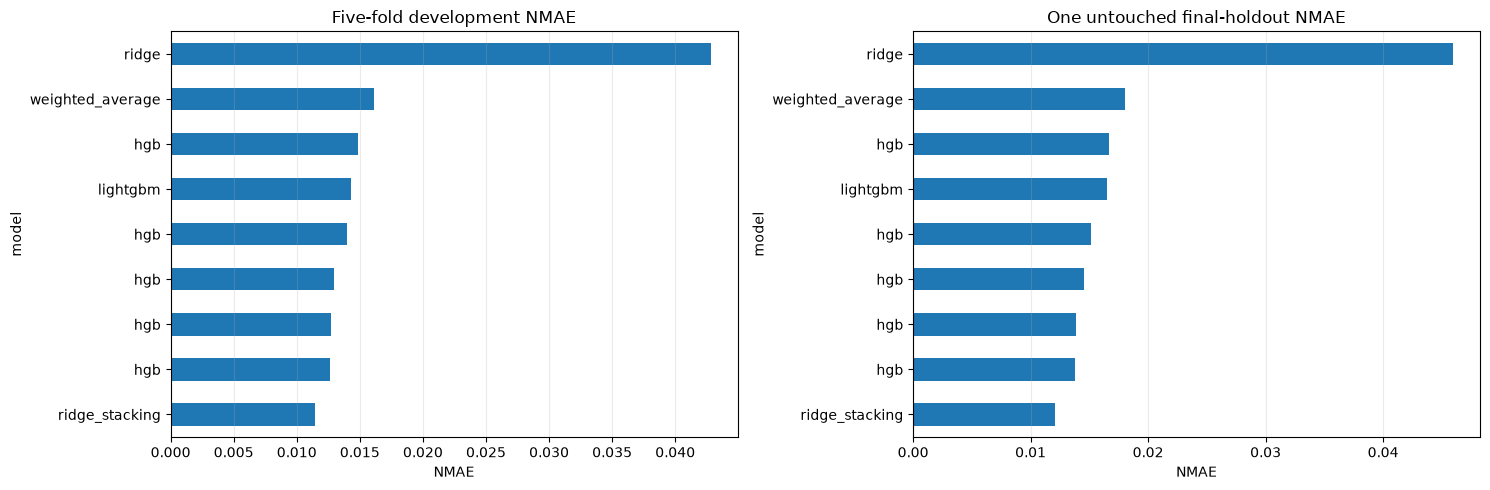

In [7]:
from sklearn.base import clone
from lightgbm import LGBMRegressor
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

RESEARCH_DIR = ARTIFACT_DIR / "bounded_research"
RESEARCH_DIR.mkdir(parents=True, exist_ok=True)
DEVELOPMENT = train.copy()
FINAL_HOLDOUT = holdout.copy()
SAFE_BASE_FEATURES = SPOT_FEATURES.copy()
SAFE_EXPANDED_FEATURES = SAFE_BASE_FEATURES + [
    "hour_sin",
    "hour_cos",
    "effective_irradiance",
    "forecast_temperature_derating",
]
HISTORY_FEATURES = [
    "target_lag_1h",
    "target_lag_24h",
    "target_lag_168h",
    "target_roll_3h",
    "target_roll_24h",
    "target_roll_std_24h",
]
FEATURE_GROUPS = {
    "forecast_only": SAFE_BASE_FEATURES,
    "calendar_physics": SAFE_EXPANDED_FEATURES,
    "lag_24": SAFE_EXPANDED_FEATURES + ["target_lag_24h"],
    "lag_24_roll_24": SAFE_EXPANDED_FEATURES + ["target_lag_24h", "target_roll_24h", "target_roll_std_24h"],
    "full_history": SAFE_EXPANDED_FEATURES + HISTORY_FEATURES,
}
LGBM_SPACE = {
    "n_estimators": [100, 300],
    "learning_rate": [0.03, 0.1],
    "num_leaves": [15, 31],
    "min_child_samples": [10, 20],
}


def add_safe_features(frame):
    result = frame.copy()
    hour = result["timestamp"].dt.hour.to_numpy(dtype=float)
    result["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    result["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    result["effective_irradiance"] = result["forecast_irradiance"] * np.clip(1 - result["forecast_cloud_cover"], 0, 1)
    result["forecast_temperature_derating"] = result["forecast_irradiance"] * np.clip(1 - 0.004 * np.maximum(result["forecast_temperature"] - 25, 0), 0, 1)
    return result


def add_observed_history(frame):
    result = add_safe_features(frame).sort_values(["plant_id", "timestamp"]).copy()
    grouped = result.groupby("plant_id", group_keys=False)["generation_mw"]
    prior = grouped.shift(1)
    result["target_lag_1h"] = prior
    result["target_lag_24h"] = grouped.shift(24)
    result["target_lag_168h"] = grouped.shift(168)
    prior_by_plant = prior.groupby(result["plant_id"], group_keys=False)
    result["target_roll_3h"] = prior_by_plant.transform(lambda values: values.rolling(3, min_periods=3).mean())
    result["target_roll_24h"] = prior_by_plant.transform(lambda values: values.rolling(24, min_periods=24).mean())
    result["target_roll_std_24h"] = prior_by_plant.transform(lambda values: values.rolling(24, min_periods=24).std())
    return result.sort_index()


def chronological_folds(frame, folds=5, validation_hours=144):
    timestamps = frame["timestamp"].drop_duplicates().sort_values().to_numpy()
    start = len(timestamps) - folds * validation_hours
    if start <= 168:
        raise ValueError("not enough development history for five chronology-preserving folds")
    for fold in range(folds):
        validation_start = timestamps[start + fold * validation_hours]
        validation_end = timestamps[start + (fold + 1) * validation_hours] if fold < folds - 1 else None
        train_fold = frame.loc[frame["timestamp"] < validation_start].copy()
        validation_fold = frame.loc[frame["timestamp"] >= validation_start].copy()
        if validation_end is not None:
            validation_fold = validation_fold.loc[validation_fold["timestamp"] < validation_end].copy()
        yield fold + 1, train_fold, validation_fold


def nmae(frame):
    return float((frame["prediction_mw"] - frame["generation_mw"]).abs().sum() / frame["capacity_mw"].sum())


def estimator_for(model_name, parameters=None):
    parameters = parameters or {}
    if model_name == "ridge":
        return ridge_pipeline()
    if model_name == "hgb":
        return make_pipeline(SimpleImputer(strategy="median"), HistGradientBoostingRegressor(random_state=SEED, max_iter=200, learning_rate=0.1, max_leaf_nodes=31))
    if model_name == "lightgbm":
        return LGBMRegressor(random_state=SEED, verbosity=-1, **parameters)
    raise ValueError(f"unknown model: {model_name}")


def recursive_history_predict(estimator, train_frame, evaluation_frame, columns):
    history = {
        plant_id: list(plant_rows.sort_values("timestamp")["generation_mw"].to_numpy(dtype=float))
        for plant_id, plant_rows in train_frame.groupby("plant_id")
    }
    predictions = pd.Series(index=evaluation_frame.index, dtype=float)
    for plant_id, plant_rows in evaluation_frame.sort_values(["plant_id", "timestamp"]).groupby("plant_id", sort=False):
        values = history[plant_id]
        for index, row in plant_rows.iterrows():
            feature_row = pd.DataFrame([row])
            feature_row["target_lag_1h"] = values[-1] if len(values) >= 1 else np.nan
            feature_row["target_lag_24h"] = values[-24] if len(values) >= 24 else np.nan
            feature_row["target_lag_168h"] = values[-168] if len(values) >= 168 else np.nan
            feature_row["target_roll_3h"] = np.mean(values[-3:]) if len(values) >= 3 else np.nan
            feature_row["target_roll_24h"] = np.mean(values[-24:]) if len(values) >= 24 else np.nan
            feature_row["target_roll_std_24h"] = np.std(values[-24:], ddof=1) if len(values) >= 24 else np.nan
            prediction = float(estimator.predict(feature_row[columns])[0])
            prediction = float(np.clip(prediction, 0, row["capacity_mw"]))
            predictions.loc[index] = prediction
            values.append(prediction)
    return predictions.reindex(evaluation_frame.index).to_numpy(dtype=float)


def oof_predictions(model_name, feature_group, parameters=None, scenario="forecast_only"):
    records = []
    columns = FEATURE_GROUPS[feature_group]
    needs_history = feature_group in {"lag_24", "lag_24_roll_24", "full_history"}
    for fold, train_fold, validation_fold in chronological_folds(DEVELOPMENT):
        if needs_history:
            combined = pd.concat([train_fold, validation_fold])
            observed = add_observed_history(combined)
            fit_frame = observed.loc[observed["timestamp"] < validation_fold["timestamp"].min()].copy()
            predict_frame = observed.loc[observed["timestamp"] >= validation_fold["timestamp"].min()].copy()
        else:
            fit_frame = add_safe_features(train_fold)
            predict_frame = add_safe_features(validation_fold)
        estimator = estimator_for(model_name, parameters).fit(fit_frame[columns], fit_frame["generation_mw"])
        if scenario == "day_ahead_recursive":
            prediction = recursive_history_predict(estimator, fit_frame, add_safe_features(validation_fold), columns)
        else:
            prediction = estimator.predict(predict_frame[columns])
        result = validation_fold[["plant_id", "timestamp", "generation_mw", "capacity_mw"]].copy()
        result["prediction_mw"] = np.clip(prediction, 0, result["capacity_mw"])
        result["fold"] = fold
        result["model"] = model_name
        result["feature_group"] = feature_group
        result["scenario"] = scenario
        records.append(result)
    return pd.concat(records, ignore_index=True)


def summarize_predictions(frame):
    return {
        "NMAE": nmae(frame),
        "MAE": float((frame["prediction_mw"] - frame["generation_mw"]).abs().mean()),
        "RMSE": float(np.sqrt(((frame["prediction_mw"] - frame["generation_mw"]) ** 2).mean())),
    }


safe_oof = {
    "ridge": oof_predictions("ridge", "calendar_physics"),
    "hgb": oof_predictions("hgb", "calendar_physics"),
}


def optuna_objective(trial):
    parameters = {name: trial.suggest_categorical(name, values) for name, values in LGBM_SPACE.items()}
    prediction_frame = oof_predictions("lightgbm", "calendar_physics", parameters)
    return nmae(prediction_frame)


study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(optuna_objective, n_trials=6)
best_lgbm_parameters = study.best_params
safe_oof["lightgbm"] = oof_predictions("lightgbm", "calendar_physics", best_lgbm_parameters)
optuna_trials = study.trials_dataframe().rename(columns={"value": "OOF_NMAE"})
optuna_trials.to_csv(RESEARCH_DIR / "optuna_trials.csv", index=False)

history_oof = {
    "lag_24": oof_predictions("hgb", "lag_24", scenario="short_horizon_observed_history"),
    "lag_24_roll_24": oof_predictions("hgb", "lag_24_roll_24", scenario="short_horizon_observed_history"),
    "full_history_observed": oof_predictions("hgb", "full_history", scenario="short_horizon_observed_history"),
    "full_history_recursive": oof_predictions("hgb", "full_history", scenario="day_ahead_recursive"),
}

safe_matrix = pd.concat(
    [frame.set_index(["plant_id", "timestamp"])["prediction_mw"].rename(name) for name, frame in safe_oof.items()],
    axis=1,
)
oof_truth = safe_oof["ridge"].set_index(["plant_id", "timestamp"])[["generation_mw", "capacity_mw"]]
model_nmae = {name: nmae(frame) for name, frame in safe_oof.items()}
weights = pd.Series({name: 1 / value for name, value in model_nmae.items()})
weights = weights / weights.sum()
weighted_prediction = safe_matrix.mul(weights, axis=1).sum(axis=1)
stacker = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(safe_matrix, oof_truth["generation_mw"])
stacked_prediction = stacker.predict(safe_matrix)
ensemble_oof = {}
for name, prediction in {"weighted_average": weighted_prediction, "ridge_stacking": stacked_prediction}.items():
    result = oof_truth.copy()
    result["prediction_mw"] = np.clip(prediction, 0, result["capacity_mw"])
    result = result.reset_index()
    result["model"] = name
    result["feature_group"] = "calendar_physics"
    result["scenario"] = "forecast_only"
    ensemble_oof[name] = result

all_oof = list(safe_oof.values()) + list(history_oof.values()) + list(ensemble_oof.values())
oof_metrics = pd.DataFrame([
    {"model": frame["model"].iat[0], "feature_group": frame["feature_group"].iat[0], "scenario": frame["scenario"].iat[0], **summarize_predictions(frame)}
    for frame in all_oof
]).sort_values("NMAE")
feature_ablation = oof_metrics.loc[oof_metrics["model"].eq("hgb")].copy()
forecast_hgb_nmae = oof_metrics.loc[(oof_metrics["model"] == "hgb") & (oof_metrics["feature_group"] == "calendar_physics"), "NMAE"].iat[0]
feature_ablation["NMAE_change_vs_forecast_hgb"] = feature_ablation["NMAE"] - forecast_hgb_nmae
weights.rename("weight").rename_axis("model").reset_index().to_csv(RESEARCH_DIR / "ensemble_weights.csv", index=False)
oof_metrics.to_csv(RESEARCH_DIR / "oof_metrics.csv", index=False)
feature_ablation.to_csv(RESEARCH_DIR / "feature_ablation.csv", index=False)


def final_prediction(model_name, feature_group, parameters=None, scenario="forecast_only"):
    columns = FEATURE_GROUPS[feature_group]
    needs_history = feature_group in {"lag_24", "lag_24_roll_24", "full_history"}
    if needs_history:
        combined = add_observed_history(pd.concat([DEVELOPMENT, FINAL_HOLDOUT]))
        fit_frame = combined.loc[combined["timestamp"] < FINAL_HOLDOUT["timestamp"].min()].copy()
        observed_holdout = combined.loc[combined["timestamp"] >= FINAL_HOLDOUT["timestamp"].min()].copy()
    else:
        fit_frame = add_safe_features(DEVELOPMENT)
        observed_holdout = add_safe_features(FINAL_HOLDOUT)
    estimator = estimator_for(model_name, parameters).fit(fit_frame[columns], fit_frame["generation_mw"])
    if scenario == "day_ahead_recursive":
        prediction = recursive_history_predict(estimator, fit_frame, add_safe_features(FINAL_HOLDOUT), columns)
    else:
        prediction = estimator.predict(observed_holdout[columns])
    result = FINAL_HOLDOUT[["plant_id", "timestamp", "generation_mw", "capacity_mw"]].copy()
    result["prediction_mw"] = np.clip(prediction, 0, result["capacity_mw"])
    result["model"] = model_name
    result["feature_group"] = feature_group
    result["scenario"] = scenario
    return result


safe_final = {
    "ridge": final_prediction("ridge", "calendar_physics"),
    "hgb": final_prediction("hgb", "calendar_physics"),
    "lightgbm": final_prediction("lightgbm", "calendar_physics", best_lgbm_parameters),
}
final_matrix = pd.concat(
    [frame.set_index(["plant_id", "timestamp"])["prediction_mw"].rename(name) for name, frame in safe_final.items()],
    axis=1,
)
final_truth = safe_final["ridge"].set_index(["plant_id", "timestamp"])[["generation_mw", "capacity_mw"]]
ensemble_final = {}
for name, prediction in {
    "weighted_average": final_matrix.mul(weights, axis=1).sum(axis=1),
    "ridge_stacking": stacker.predict(final_matrix),
}.items():
    result = final_truth.copy()
    result["prediction_mw"] = np.clip(prediction, 0, result["capacity_mw"])
    result = result.reset_index()
    result["model"] = name
    result["feature_group"] = "calendar_physics"
    result["scenario"] = "forecast_only"
    ensemble_final[name] = result
history_final = {
    "lag_24": final_prediction("hgb", "lag_24", scenario="short_horizon_observed_history"),
    "lag_24_roll_24": final_prediction("hgb", "lag_24_roll_24", scenario="short_horizon_observed_history"),
    "full_history_observed": final_prediction("hgb", "full_history", scenario="short_horizon_observed_history"),
    "full_history_recursive": final_prediction("hgb", "full_history", scenario="day_ahead_recursive"),
}
all_final = list(safe_final.values()) + list(ensemble_final.values()) + list(history_final.values())
holdout_metrics = pd.DataFrame([
    {"model": frame["model"].iat[0], "feature_group": frame["feature_group"].iat[0], "scenario": frame["scenario"].iat[0], **summarize_predictions(frame)}
    for frame in all_final
]).sort_values("NMAE")
all_predictions = pd.concat(all_final, ignore_index=True)
holdout_metrics.to_csv(RESEARCH_DIR / "holdout_metrics.csv", index=False)
all_predictions.to_csv(RESEARCH_DIR / "holdout_predictions.csv", index=False)

figure, axes = plt.subplots(1, 2, figsize=(15, 5))
oof_metrics.sort_values("NMAE").plot.barh(x="model", y="NMAE", ax=axes[0], legend=False, title="Five-fold development NMAE")
holdout_metrics.sort_values("NMAE").plot.barh(x="model", y="NMAE", ax=axes[1], legend=False, title="One untouched final-holdout NMAE")
for axis in axes:
    axis.set_xlabel("NMAE")
    axis.grid(axis="x", alpha=0.25)
plt.tight_layout()

print("AIDM-aligned bounded Optuna search:", {"trials": len(study.trials), "best_parameters": best_lgbm_parameters, "best_oof_nmae": study.best_value})
print("Forecast-only ensemble weights:", weights.round(3).to_dict())
print("Target-history comparison: positive NMAE_change_vs_forecast_hgb means the history bundle hurt relative to the forecast-only HGB baseline.")
display(feature_ablation.sort_values("NMAE"))
display(holdout_metrics)

Full target history changes OOF NMAE by -0.0022 with observed short-horizon history and -0.0021 with recursive day-ahead history.


,model,feature_group,scenario,plant_id,absolute_error,capacity_mw,NMAE
4,hgb,full_history,day_ahead_recursive,plant_01,267.892411,18144.0,0.014765
5,hgb,full_history,day_ahead_recursive,plant_02,343.028759,23760.0,0.014437
6,hgb,full_history,day_ahead_recursive,plant_03,355.863606,29376.0,0.012114
7,hgb,full_history,day_ahead_recursive,plant_04,506.187425,34992.0,0.014466
28,ridge_stacking,calendar_physics,forecast_only,plant_01,226.426392,18144.0,0.012479
32,weighted_average,calendar_physics,forecast_only,plant_01,236.573977,18144.0,0.013039
20,lightgbm,calendar_physics,forecast_only,plant_01,289.067140,18144.0,0.015932
0,hgb,calendar_physics,forecast_only,plant_01,301.119694,18144.0,0.016596
24,ridge,calendar_physics,forecast_only,plant_01,1092.858845,18144.0,0.060233
29,ridge_stacking,calendar_physics,forecast_only,plant_02,278.258205,23760.0,0.011711


,horizon_bucket,absolute_error,capacity_mw,NMAE
0,0-23h,79.397636,5904.0,0.013448
1,24-47h,77.802387,5904.0,0.013178
2,48-71h,73.988234,5904.0,0.012532
3,72-95h,72.041186,5904.0,0.012202
4,96h+,1169.742757,82656.0,0.014152


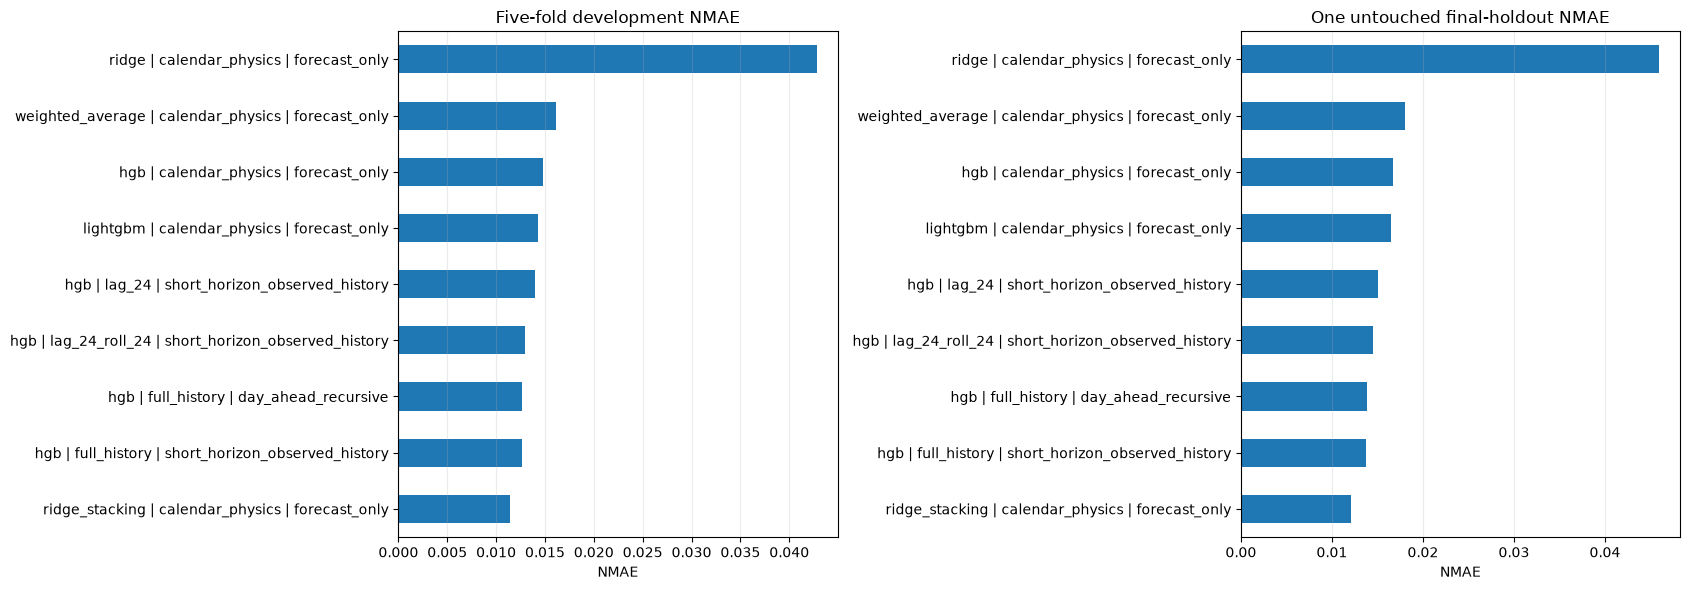

In [8]:
# Make the lag/rolling trade-off visible by plant and by recursive forecast horizon.
metric_keys = ["model", "feature_group", "scenario"]
per_plant_metrics = (
    all_predictions.assign(absolute_error=lambda frame: (frame["prediction_mw"] - frame["generation_mw"]).abs())
    .groupby(metric_keys + ["plant_id"], as_index=False)
    .agg(absolute_error=("absolute_error", "sum"), capacity_mw=("capacity_mw", "sum"))
)
per_plant_metrics["NMAE"] = per_plant_metrics["absolute_error"] / per_plant_metrics["capacity_mw"]
per_plant_metrics.to_csv(RESEARCH_DIR / "per_plant_nmae.csv", index=False)

recursive_horizon = all_predictions.loc[
    (all_predictions["model"] == "hgb")
    & (all_predictions["feature_group"] == "full_history")
    & (all_predictions["scenario"] == "day_ahead_recursive")
].copy()
recursive_horizon["horizon_hour"] = (
    (recursive_horizon["timestamp"] - recursive_horizon["timestamp"].min()).dt.total_seconds() / 3600
).astype(int)
recursive_horizon["horizon_bucket"] = pd.cut(
    recursive_horizon["horizon_hour"],
    bins=[-1, 23, 47, 71, 95, np.inf],
    labels=["0-23h", "24-47h", "48-71h", "72-95h", "96h+"],
)
recursive_horizon_metrics = (
    recursive_horizon.assign(absolute_error=lambda frame: (frame["prediction_mw"] - frame["generation_mw"]).abs())
    .groupby("horizon_bucket", observed=False, as_index=False)
    .agg(absolute_error=("absolute_error", "sum"), capacity_mw=("capacity_mw", "sum"))
)
recursive_horizon_metrics["NMAE"] = recursive_horizon_metrics["absolute_error"] / recursive_horizon_metrics["capacity_mw"]
recursive_horizon_metrics.to_csv(RESEARCH_DIR / "recursive_horizon_nmae.csv", index=False)

history_summary = feature_ablation.set_index(["feature_group", "scenario"])["NMAE_change_vs_forecast_hgb"]
full_observed_change = history_summary.loc[("full_history", "short_horizon_observed_history")]
full_recursive_change = history_summary.loc[("full_history", "day_ahead_recursive")]
print(f"Full target history changes OOF NMAE by {full_observed_change:+.4f} with observed short-horizon history and {full_recursive_change:+.4f} with recursive day-ahead history.")
display(per_plant_metrics.sort_values(["scenario", "plant_id", "NMAE"]))
display(recursive_horizon_metrics)

figure, axes = plt.subplots(1, 2, figsize=(17, 6))
for axis, metric_frame, title in (
    (axes[0], oof_metrics, "Five-fold development NMAE"),
    (axes[1], holdout_metrics, "One untouched final-holdout NMAE"),
):
    plotted = metric_frame.copy()
    plotted["label"] = plotted["model"] + " | " + plotted["feature_group"] + " | " + plotted["scenario"]
    plotted.sort_values("NMAE").plot.barh(x="label", y="NMAE", ax=axis, legend=False, title=title)
    axis.set_xlabel("NMAE")
    axis.set_ylabel("")
    axis.grid(axis="x", alpha=0.25)
plt.tight_layout()

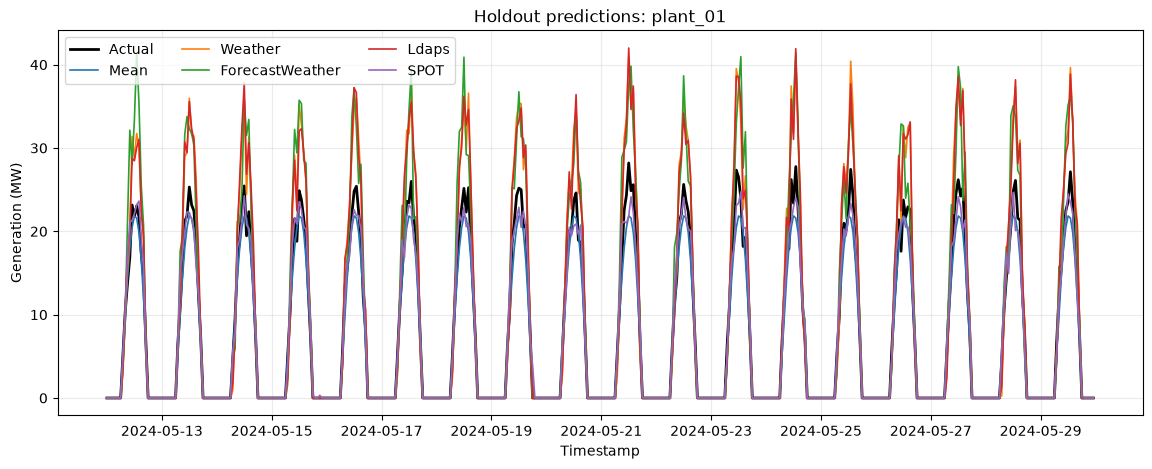

In [2]:
import matplotlib.pyplot as plt

plot_plant = holdout["plant_id"].iat[0]
figure, axis = plt.subplots(figsize=(14, 5))
for model_name, prediction_frame in models.items():
    plant_frame = prediction_frame.loc[prediction_frame["plant_id"] == plot_plant]
    if model_name == "Mean":
        axis.plot(plant_frame["timestamp"], plant_frame["generation_mw"], color="black", linewidth=2, label="Actual")
    axis.plot(plant_frame["timestamp"], plant_frame["prediction_mw"], linewidth=1.2, label=model_name)
axis.set(title=f"Holdout predictions: {plot_plant}", xlabel="Timestamp", ylabel="Generation (MW)")
axis.legend(ncol=3)
axis.grid(alpha=0.25)
plt.show()

## 결론

이 합성 데이터 연구에서는 다음 네 가지 실무적 결론을 얻었습니다.

1. **제한된 시간순 탐색을 기본 연구 절차로 사용합니다.** 6회 Optuna TPE 탐색은 `n_estimators=300`, `learning_rate=0.03`, `num_leaves=15`, `min_child_samples=10`인 LightGBM 파라미터를 선택했고, 5-fold 개발 NMAE는 **0.01428**이었습니다. 최종 20% holdout은 이 선택 과정에서 분리했습니다.
2. **이 합성 시스템에서는 일 단위 발전량 이력이 도움이 됐습니다.** 예보 전용 HGB의 5-fold NMAE는 **0.01483**이었습니다. `lag_24`를 추가하면 **0.01396**, 24시간 rolling 평균과 표준편차를 함께 추가하면 **0.01292**, 전체 lag/rolling 세트는 관측 이력을 쓸 수 있는 단기 예측 시나리오에서 **0.01260**까지 개선됐습니다. 따라서 먼저 일 단위 lag를 확인하고, 발전소별 cross-fold 개선이 일관될 때만 rolling 집계를 추가하는 것이 적절합니다.
3. **하루 전 재귀 이력에는 작지만 실제적인 비용이 있습니다.** 같은 전체 이력 세트는 holdout 실제값 대신 이전 예측값을 되먹였을 때 **0.01269**를 기록했습니다. 최종 holdout의 horizon 구간별 NMAE는 약 **0.0122**~**0.0142**로, 이 합성 예제에서는 통제되지 않은 오차 누적이 나타나지 않았습니다. 실제 운영에서는 여전히 horizon과 발전소별로 이를 모니터링해야 합니다.
4. **예보 전용 결과에서는 stacking이 가장 좋았습니다.** OOF로 학습한 Ridge stacker의 최종 holdout NMAE는 **0.01211**로 개별 예보 전용 모델보다 낮았습니다. 가중치와 계수는 모두 개발 OOF 예측으로만 학습해 최종 holdout 누수를 막았습니다.

발전량 이력 피처는 **교육용 운영 시나리오 비교**이며 AIDM 제안 피처가 아닙니다. 저장소 로컬 AIDM 계약은 예측 시점 입력만 허용하고 `generation_mw`에서 파생한 피처를 거부합니다. 다음 AIDM 준비 실험에서는 안전한 달력·예보 날씨 피처와 제한된 LightGBM 탐색을 이어가고, 발전량 이력의 이점은 단기 예측 또는 재귀 제품 설계의 별도 의사결정으로 다뤄야 합니다.